_Técnicas de Aprendizaje Automático_

_Máster Universitario en Inteligencia Artificial_

# Caso Grupal: Clasificación de mensajes de odio

## Objetivos

Mediante este trabajo se pretende que el estudiante ponga en práctica la aplicación de un proceso completo de machine learning a la clasificación de mensajes de odio.

El objetivo es generar un proyecto completo de machine learning para clasificar mensajes de odio. Debe detallar los pasos que hay que realizar para la clasificación de mensajes, así como una evaluación de los resultados.

- Decidir la técnica de aprendizaje automático a utilizar
- Analizar diferentes modelos de aprendizaje supervisado para la clasificación de mensajes de odio.
- Evaluar los resultados obtenidos por cada modelo en términos de precisión, recall, y f1.

## Descripción de la actividad

La empresa SureTech Innovations quiere implementar un clasificador de mensajes de odio. Para ello se deben entrenar diferentes modelos de clasificación, evaluar el rendimiento de cada uno de ellos, y finalmente, decidir cuál sería el mejor.

Para llevar a cabo esta actividad cuentas con el dataset simplificado de HateSpeech "out.csv", que encontrarás en la misma página del campus donde están las instrucciones y este notebook.

Los pasos que se deben seguir para desarrollar esta actividad son:

1.	¿Qué tarea de aprendizaje automático se pretende resolver? ¿Qué análisis previos serían necesarios realizar para saber si es posible construir el modelo que buscamos? Realiza un análisis exploratorio de datos adecuado a la tarea que se pretende resolver y al dataset facilitado. Explica con detalle, en base a la tarea que se quiere resolver, qué análisis serían necesarios realizar sobre los datos.

2.	En base a la tarea que se pide realizar y a las características del dataset decide qué algoritmo o algoritmos se deben utilizar. Implementa tres modelos. Realiza los entrenamientos necesarios para cada uno de ellos. Explica por qué son convenientes los algoritmos elegidos.

3.	Realiza una explicación de las métricas de evaluación que se deben utilizar para valorar la bondad del modelo. Justifica la decisión de las elegidas. ¿Cómo habría que evaluar el modelo? Evalúa los modelos entrenados en el punto anterior y explica los resultados obtenidos.


## Dataset

El dataset original proporcionado en el proyecto transversal ha sido adaptado para la realización de esta actividad. Esa adaptación ha incluido:

- Eliminación de nulos y duplicados
- Eliminación de URLs, emojis y menciones a los periódicos
- Eliminación de filas vacías
- Limpieza y homogeneización de datos.
    - Convertir la totalidad del texto a minúscula
    - Eliminar signos de puntuación
    - Eliminar números
    - Eliminar espacios en blanco adicionales
    - Eliminar palabras con longitud menor a 2 caracteres
    - Eliminar stopwords
    - Tokenización
    - Lematización
- Proceso de extracción de características
    - Conteo de palabras positivas (A)
    - Conteo de palabras negativas (B)
    - Conteo del número de bigrams más comunes (C)
    - Conteo del número de menciones a otros usuarios (D)
    - Categoría del sentimiento según librería ‘pysentimiento’ en español (E)

- Estandarización de las características (A_t,..E_t)
- Combinación de características f1*fi (iA..iE) (Valor1,..Valor10).

## EDA

1. La tarea que se pretende resolver es la clasificación BINARIA a partir de unas caracteristicas proporcionadas. En concreto, el objetivo de los modelos es asignar a la variable 'label' un valor 1 si el comentario contiene odio y 0 en caso contrario.
2. El dataset utilizado contiene 22 columnas, 10000 filas sin filas vacías y sin valores ausentes.

3. Características "primarias" (resultado de la extracción): A,B,C,D son cuantitativas y E es categórica.
4. Variables calculadas a partir de las primarias: (A_t,..E_t) y (Valor_1, .. Valor_10), todas cuantitativas

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#carga de datos del fichero
df = pd.read_csv("out_act3.csv", encoding = 'latin-1')

print(f"El dataset contiene: {df.shape[0]} filas x {df.shape[1]} columnas")
#df.head()
df.describe()


El dataset contiene: 10000 filas x 22 columnas


,A,B,C,D,E,label,A_t,B_t,C_t,D_t,...,Valor_1,Valor_2,Valor_3,Valor_4,Valor_5,Valor_6,Valor_7,Valor_8,Valor_9,Valor_10
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.957400,26.098100,5.674600,0.091300,2.200600,0.500000,0.735989,0.895389,1.014276,-0.241571,...,2.448370,2.515129,-0.222304,-0.324603,3.343632,-0.302639,-0.756762,-0.286422,-0.357238,-0.050935
std,1.741864,34.012341,7.317149,0.352671,2.729488,0.500025,1.863010,1.672944,1.844389,0.676008,...,8.690527,9.827254,1.160914,1.547278,10.567912,1.045447,0.885760,1.218960,1.297408,1.129825
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.287998,-0.388282,-0.416086,-0.416577,...,-2.197166,-3.582457,-10.573231,-11.207779,-1.393841,-6.558948,-8.362074,-9.067027,-11.559651,-5.886890
25%,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-0.287998,-0.339096,-0.164022,-0.416577,...,-0.086494,-0.097950,-0.432068,-0.686619,-0.025057,-0.760297,-0.943189,-0.561697,-0.716113,-0.993166
50%,0.000000,5.000000,3.000000,0.000000,0.000000,0.500000,-0.287998,-0.142350,0.340105,-0.416577,...,0.097659,0.047238,0.119973,-0.415081,0.063687,-0.043150,-0.808442,-0.141680,-0.314500,0.221244
75%,1.000000,46.000000,7.000000,0.000000,6.000000,1.000000,0.781552,1.874292,1.348361,-0.416577,...,1.157323,0.659812,0.119973,0.152955,2.527222,0.141260,-0.314174,0.068328,0.087112,0.221244
max,24.000000,328.000000,88.000000,6.000000,6.000000,1.000000,25.381200,15.744855,21.765536,11.084360,...,332.263677,246.545947,21.283302,60.511589,331.989523,20.009412,19.361276,28.053013,23.045933,17.286505


In [36]:
#veamos si estan balanceadas segun label
balance = df['label'].value_counts()
print(balance)

label
0.0    5000
1.0    5000
Name: count, dtype: int64


Por tanto, los datos están PERFECTAMENTE balanceados según las clases 0 y 1 de label, lo cual indica que muy probablemente se ha muestreado un corpus de mayor tamaño para obtener esta proporción. Obviamente, este no sería el caso de un dataset real de datos, por lo que deberemos tener en cuenta esta vinculación con el procesado anterior a la hora de interpretar las mediciones aportadas en prebas posteriores.

In [37]:
# DUPLICADOS?
n_dup = df.duplicated().sum()
print(f"Filas duplicadas: {n_dup}  ({100*n_dup/len(df):.1f}% del total)\n")
# Reparto por clase de las filas duplicadas
dup_por_clase = df[df.duplicated()]["label"].value_counts()
for lab, cnt in dup_por_clase.items():
    nombre = "no odio" if lab == 0.0 else "odio"
    print(f"  Clase {int(lab)} ({nombre}): {cnt}  ({100*cnt/n_dup:.1f}% de los duplicados)")
# NULOS?
print(f"\nValores nulos en total:   {df.isnull().sum().sum()}")

Filas duplicadas: 539  (5.4% del total)

  Clase 1 (odio): 509  (94.4% de los duplicados)
  Clase 0 (no odio): 30  (5.6% de los duplicados)

Valores nulos en total:   0


In [38]:
#  evaluar la correlación de A,B,C,D con label utilizando Pearson...
corr_mat = df[['A','B','C','D']].corrwith(df['label'])
corr_mat

A   -0.380072
B   -0.731174
C   -0.509732
D    0.130156
dtype: float64

En estos resultados hay uno que nos llama particularmente la atención: el recuento de palabras Negativas tiene una correlación con no_odio/odio de -0.731 lo cual nos llevaría a pensar que cuantas más palabras negativas en un comentario, menor proabilidad de que éste sea catalogado como odio. Sin embargo, inspeccionando los datos en el dataset, comprobamos que los mensajes con no_odio tienen una longitud considerablemente mayor que los de odio.
Haremos un test para comprobar cuál es la probabilidad por palabras negativas en odio y no_odio (y no por mensaje)

In [39]:

# Longitud del mensaje = nº de lemas en 'comentario' (separados por comas)
df["len"] = df["comentario"].fillna("").apply(
    lambda s: 0 if s == "" else s.count(",") + 1
)

# Densidad de palabras negativas: B por palabra (por fila)
df["B_densidad"] = df["B"] / df["len"].replace(0, pd.NA)

tabla = (df.groupby("label")
         .agg(B_medio=("B", "mean"),
              longitud_media=("len", "mean"),
              B_por_palabra=("B_densidad", "mean"))
         .round(3))
tabla.index = tabla.index.map({0.0: "no odio", 1.0: "odio"})
display(tabla)

,B_medio,longitud_media,B_por_palabra
label,,,
no odio,50.966,383.977,0.135
odio,1.230,10.349,0.110


Este ultimo resultado tampoco es muy intuitivo, ya que indica que en un mensaje etiquetado como no_odio hay un porcentaje mayor de palabras negativas que en un mensaje con etiqueta odio.


In [40]:
# Correlación de B con la longitud del mensaje
print("Correlación B vs longitud:", round(df["B"].corr(df["len"]), 3))

Correlación B vs longitud: 0.97


Efectivamente, B y longitud del mensaje estan fuertemente relacionados... pero creemos que profundizar en este análisis no es cometido de esta tarea, ya que sería entrar a valorar el procesado anterior que produjo los conteos proporcionados, del que no disponemos de información. Además, B no es interpretable sin normalizar por longitud, es decir, se tendría que utilizar algún tipo de conteo relativo.
Seguimos el analisis con la variable E, para que haremos una tabla de contingencia de chi-squared

In [41]:
#para la variable E haremos un chi-squared
from scipy.stats import chi2_contingency

# Tabla de contingencia
tabla = pd.crosstab(df["E"], df["label"])
print("Tabla de contingencia (E x label):")
print(tabla)
# Test chi-cuadrado de independencia
chi2, p_valor, gl, esperado = chi2_contingency(tabla)
# V de Cramér
n = tabla.values.sum()
k = min(tabla.shape) - 1
cramers_v = np.sqrt(chi2 / (n * k))

print(f"\nχ^2: {chi2:.2f}")
print(f"p-valor: {p_valor:.3e}")

print(f"V de Cramer:{cramers_v:.3f}")


Tabla de contingencia (E x label):
label   0.0   1.0
E                
0      4671   942
1       163   226
2        73   196
3        34   144
4        23   171
5        19   354
6        17  2967

χ^2: 5941.95
p-valor: 0.000e+00
V de Cramer:0.771


Como tenemos un numero limitado de muestras, evaluamos la V de Cramer: 0.771 es más proximo a 1 que a 0, por lo cual determinamos que 'E' y 'label' están relacionadas.
Ahora pasamos a hacer un box diagram para evaluar la separabilidad de las variables:

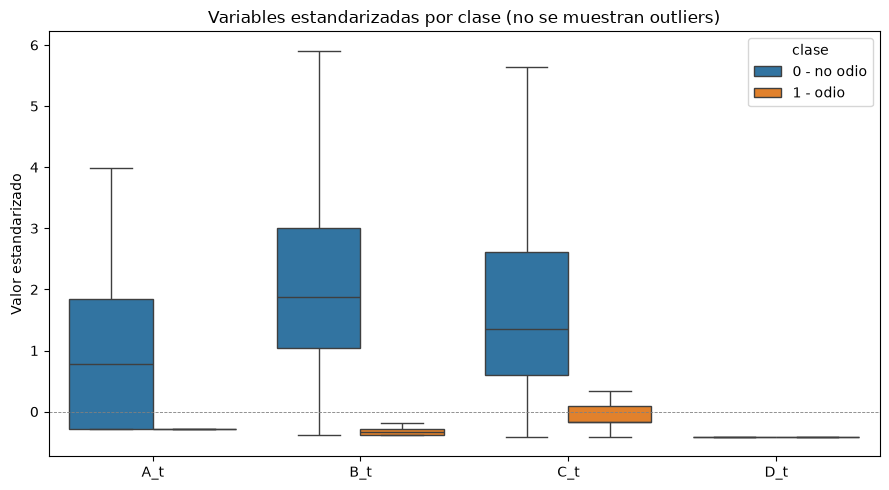

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
#usaremos las variables estandarizadas para generar los box plots (para tener un único eje vertical)
std_features = ["A_t", "B_t", "C_t", "D_t"]
#version de formato 'long' del dataset
long = df.melt(id_vars="label", value_vars=std_features,
               var_name="variable", value_name="valor")
long["clase"] = long["label"].map({0.0: "0 - no odio", 1.0: "1 - odio"})

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=long, x="variable", y="valor", hue="clase",
            showfliers=False, ax=ax)
ax.set_title("Variables estandarizadas por clase (no se muestran outliers)")
ax.set_xlabel("")
ax.set_ylabel("Valor estandarizado")
ax.axhline(0, color="grey", lw=0.6, ls="--")
plt.tight_layout()
plt.show()

Con estos datos podemos determinar que:
1. El problema cuenta con datos suficientemente saneados para ser abordado: las dos clases están representadas y balanceadas. No hay valores nulos y hay  539 duplicados exactos, concentrados casi por completo en la clase de odio (509 de 539). Eliminar estos datos crearía un desbalanceo menor que se puede gestionar con una partición estratificada
2. En cuanto a las variables cuantitativas "primarias" A,B y C muestran media/alta correlación con la variable objetivo (A: -0.380  B: -0.731 C: -0.510) mientras que la variable D parece aportar poco a la predicción de la variable objetivo. Tal como hemos comentado anteriormente, es destacable que B tenga una correlación negativa con odio/no_odio (hemos incluido un análisis respecto a la longitud que parece apuntar una fuerte dependencia con este atributo del texto). Sin embargo, este hecho no forma parte de nuestra tarea, ya que estaríamos haciendo observaciones dobre el proceso que dió lugar a estos conteos, del que no tenemos información.
3. La variable categórica E nos presenta dudas sobre la legitimidad de su inclusión en el estudio: es una variable que proviene de una clasificación que ha usado los mismos datos de entrada, con un entrenamiento similar (odio es un tipo de sentimiento). Por tanto, donde sea posible, haremos pruebas con y sin ella para evaluar el rendimiento de los modelos sin esta "ayuda externa".
4. Dicho esto, E separa bien la variable objetivo: (no_odio-0: 93.4%; odio-6:59.3%), lo cual es coherente con el mecanismo que la ha generado: sería de esperar que en el conjunto de Emociones Ekman la ira por ejemplo pueda asociarse al odio y la alegría al no_odio. Sin embargo, como no disponemos de la codificación de esta varaible, no podemos afirmar qué emoción corresponde a cada valor numérico. Trataremos E como variable categórica.
5. En cuanto a las variables calculadas, vemos que el cálculo de la estandarización se ha realizado teniendo en cuenta el total de los datos, por lo que no podremos usar estas variables para entrenar los modelos (la normalización debe hacerse en datos de entrenamiento y validación por separado)
6. Finalmente, el diagrama de cajas (generado con columnas estandarizadas para poder tener un eje Y común) muestra una clara separabilidad de las variables cuantitativas, siendo D la excepción, ya que no presenta separación apreciable entre clases.

## SELECCIÓN Y ENTRENAMIENTO DE LOS MODELOS

Para seleccionar los dos modelos con los que trabajar nos basaremos en los resultados obtenidos en la EDA anterior:
1. Clases separables (como muestran los boxplots)
2. 4 clases cuantitativas y 1 categórica
3. Valores medios/altos en algunas de las correlaciones de las características
Por lo anterior, un candidato firme es Logistic Regression por su condición de lineal e interpretable.

Escogido LR como primer modelo, sería interesante buscar un modelo con método de clasificación lo más diferente posible, entre otras cosas para evitar que similitudes algorítmicas empobrezcan la comparativa.
Dentro de los modelos basados en árboles de decisión, destaca Random Forest por su condición contraria a la interpretabilidad.
La combinación LR + RF también nos permitirá evaluar la condición de linealidad del problema: si los resultados de RF son muy superiores a los de LR sabremos que estamos ante un problema con interacciones no lineales relevantes.

Por tanto, optaremos por Logistic Regression + Random Forest


In [43]:
#Celda previa donde generamos los splits para ambos modelos...

from sklearn.model_selection import train_test_split

# Eliminar duplicados exactos ANTES del inicio...
df_model = df.drop_duplicates().reset_index(drop=True)

num_features = ["A", "B", "C", "D"]
cat_features = ["E"]# categórica (emotion_analyzer), se tratará como nominal

X = df_model[num_features + cat_features]
y = df_model["label"]

# Estratificamos los datos y separamos en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

In [44]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Preprocesado: escalado y one-hot encoding para la categórica E.
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

model_lr = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000)),
])

model_lr.fit(X_train, y_train)

# Comprobación rápida (la evaluación formal está ne la Tarea 3)
print("-----Regresión Logística-------(con E)")
print("Exactitud Entreno:", round(model_lr.score(X_train, y_train), 4))
print("Exactitud Test:", round(model_lr.score(X_test, y_test), 4))

-----Regresión Logística-------(con E)
Exactitud Entreno: 0.9753
Exactitud Test: 0.9713


In [45]:
# Modelo 1 — variante SIN E

model_lr_noE = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000)),
])
model_lr_noE.fit(X_train[num_features], y_train)
print("-----Regresión Logística-------(sin E)")
print("Exactitud Entreno (sin E):", round(model_lr_noE.score(X_train[num_features], y_train), 4))
print("Exactitud Validacion (sin E):", round(model_lr_noE.score(X_test[num_features], y_test), 4))

-----Regresión Logística-------(sin E)
Exactitud Entreno (sin E): 0.9708
Exactitud Validacion (sin E): 0.967


El segundo modelo será

RANDOM FOREST

In [46]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest sobre las variables A,B,C,D,E:
# no se necesita escalar ni realizar un one-hot encoding...

model_rf = Pipeline([
    ("prep", preprocess),  # <-- se usa E como categórica nominal
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )),
])

model_rf.fit(X_train, y_train) # X_train ya contiene A,B,C,D,E
print("-----Random Forest-------(con E)")
print("Exactitud Entreno:", round(model_rf.score(X_train, y_train), 4))
print("Exactitud Validacion :", round(model_rf.score(X_test, y_test), 4))

-----Random Forest-------(con E)
Exactitud Entreno: 0.9869
Exactitud Validacion : 0.9772


In [47]:
model_rf_noE = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
model_rf_noE.fit(X_train[num_features], y_train)
print("-----Random Forest-------(sin E)")
print("Exactitud Entrenamiento:", round(model_rf_noE.score(X_train[num_features], y_train), 4))
print("Exactitud Validacion: ", round(model_rf_noE.score(X_test[num_features], y_test), 4))

-----Random Forest-------(sin E)
Exactitud Entrenamiento: 0.98
Exactitud Validacion:  0.9691


## EVALUACIÓN DE LOS MODELOS Y COMPARATIVA

Para la evaluación se ha tenido en cuenta el tipo de tarea a realizar, el EDA y las métricas que mejor describan los modelos seleccionados, destacando el uso de múltiples métricas globales para lograr una mayor compresión del rendimiento:

1. Precision: qué proporción de los mensajes se ha clasificado como odio cuando realmente no lo eran. Un valor alto significa pocos falsos positivos.

2. Recall: qué porporción de los mensajes de odio reales ha sido correctamente detectado. Un valor alto significa pocos falsos negativos.

3. F1-score: combinación de precision y recall en una única métrica. El objetivo es penalizar modelos que tienen buenos resultados en una de ellas pero no en la otra. En esta métrica se buscará equilibrio, un valor alto significa buen balance entre detectar odio y evitar errores.

4. Acurracy: porcentaje total de predicciones correctas. En este caso el dataset está totalmente balanceado, por lo que esta métrica es engañosa, ya que no distingue tipo de errores (falsos positivos vs falsos negativos) y dos modelos con la misma accuracy pueden tener comportamientos totalmente distintos.

Para esta tarea, se ha considerado primordial la prioridad de detectar odio (recall); tener muchos falsos negativos significa que no se detectan adecuadamente los mensajes de odio, pudiendo causar daño en la red social e impacto directo en personas.

Se emplea una combinación de técnicas para los algoritmos desarrollados:

- Hold-out estratificado: división del dataset en train/test manteniendo proporción de las clases.
- Validación cruzada: se obtendrán estimaciones más robustas del rendimiento al intercambiar los datos de train/test en k-folds.
- ROC-AUC: se medirá la capacidad de los modelos para discriminar entre clases en distintos tipos de umbrales.

In [48]:
#Generamos los datasets para las predicciones (y así no tener que recalcularlos en cada celda)

y_pred_lr     = model_lr.predict(X_test)
y_pred_lr_noE = model_lr_noE.predict(X_test[num_features])
y_pred_rf     = model_rf.predict(X_test)
y_pred_rf_noE = model_rf_noE.predict(X_test[num_features])

# Scores de la clase odio (para curvas ROC y PR:necesitan probabilidades)
y_score_lr = model_lr.predict_proba(X_test)[:, 1]
y_score_rf = model_rf.predict_proba(X_test)[:, 1]


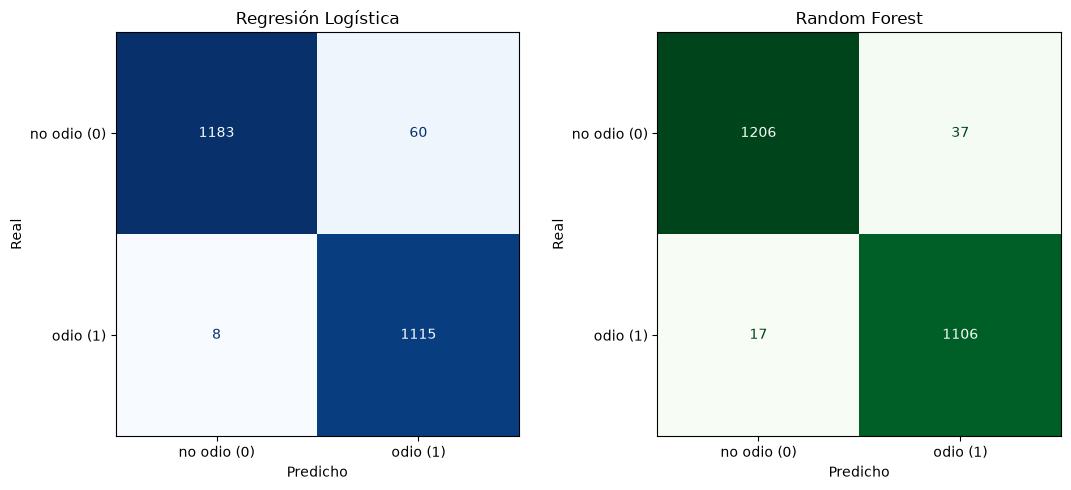

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, ax=axes[0], cmap="Blues", colorbar=False,
    display_labels=["no odio (0)", "odio (1)"])
axes[0].set_title("Regresión Logística")
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, ax=axes[1], cmap="Greens", colorbar=False,
    display_labels=["no odio (0)", "odio (1)"])
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicho"); axes[1].set_ylabel("Real")

plt.tight_layout(); plt.show()

In [50]:
from sklearn.metrics import classification_report

print("REGRESIÓN LOGÍSTICA")
print(classification_report(y_test, y_pred_lr, target_names=["no odio (0)", "odio (1)"], digits=3))

print("RANDOM FOREST")
print(classification_report(y_test, y_pred_rf, target_names=["no odio (0)", "odio (1)"], digits=3))

REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

 no odio (0)      0.993     0.952     0.972      1243
    odio (1)      0.949     0.993     0.970      1123

    accuracy                          0.971      2366
   macro avg      0.971     0.972     0.971      2366
weighted avg      0.972     0.971     0.971      2366

RANDOM FOREST
              precision    recall  f1-score   support

 no odio (0)      0.986     0.970     0.978      1243
    odio (1)      0.968     0.985     0.976      1123

    accuracy                          0.977      2366
   macro avg      0.977     0.978     0.977      2366
weighted avg      0.977     0.977     0.977      2366



Vemos en la tabla anterior que ambos modelos consiguen resultados satisfactorios de precision, al rededor de 95% en odio.
En cuanto a recall, la métrica que más interesa respecto a esta tarea para poder capturar los mensajes de odio, obtenemos un ~98%, lo cual es un resultado satisfactorio, siendo ligeramente más eficiente en Regresión Logística que en Random Forest. Sin embargo, Random Forest obtiene mejores métricas globales (F1-score), lo que indica más equilibrio entre precision y recall.

In [51]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

all_features = num_features + cat_features   # A, B, C, D, E
cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_cv = df_model["label"].astype(int)   # int para el scorer de recall

f1  = cross_val_score(model_lr, df_model[all_features], y_cv, cv=cv, scoring="f1_macro")
rec = cross_val_score(model_lr, df_model[all_features], y_cv, cv=cv, scoring="recall")
print(f"RL -> F1 macro: {f1.mean():.4f} ± {f1.std():.4f} // recall odio: {rec.mean():.4f} ± {rec.std():.4f}")

f1  = cross_val_score(model_rf, df_model[all_features], y_cv, cv=cv, scoring="f1_macro")
rec = cross_val_score(model_rf, df_model[all_features], y_cv, cv=cv, scoring="recall")
print(f"RF -> F1 macro: {f1.mean():.4f} ± {f1.std():.4f} // recall odio: {rec.mean():.4f} ± {rec.std():.4f}")

RL -> F1 macro: 0.9740 ± 0.0034 // recall odio: 0.9918 ± 0.0029
RF -> F1 macro: 0.9777 ± 0.0027 // recall odio: 0.9768 ± 0.0049


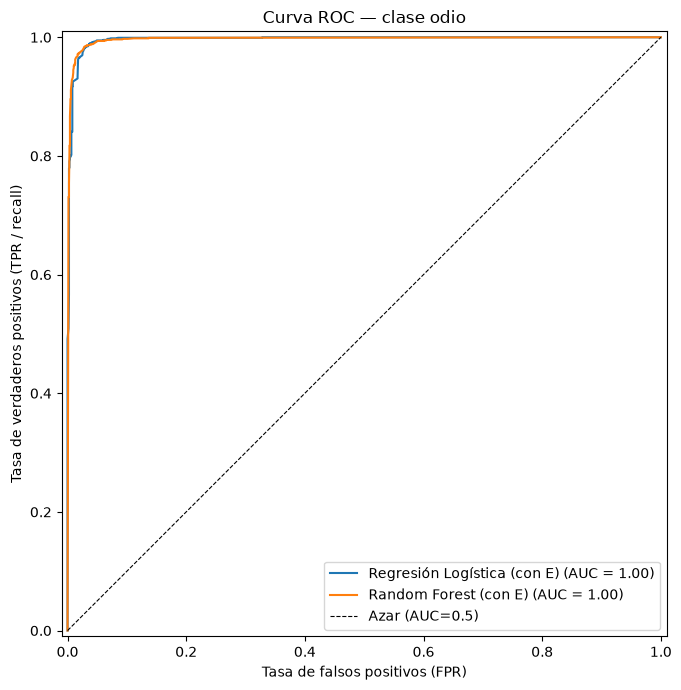

ROC-AUC RL: 0.996
ROC-AUC RF: 0.996


In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, roc_auc_score

fig, ax = plt.subplots(figsize=(7, 7))
RocCurveDisplay.from_predictions(y_test, y_score_lr, name="Regresión Logística (con E)", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_score_rf, name="Random Forest (con E)", ax=ax)
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Azar (AUC=0.5)")
ax.set_title("Curva ROC — clase odio")
ax.set_xlabel("Tasa de falsos positivos (FPR)")
ax.set_ylabel("Tasa de verdaderos positivos (TPR / recall)")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

print("ROC-AUC RL:", round(roc_auc_score(y_test, y_score_lr), 3))
print("ROC-AUC RF:", round(roc_auc_score(y_test, y_score_rf), 3))

CALCULOS SIN UTILIZAR LA VARIABLE E -----------------


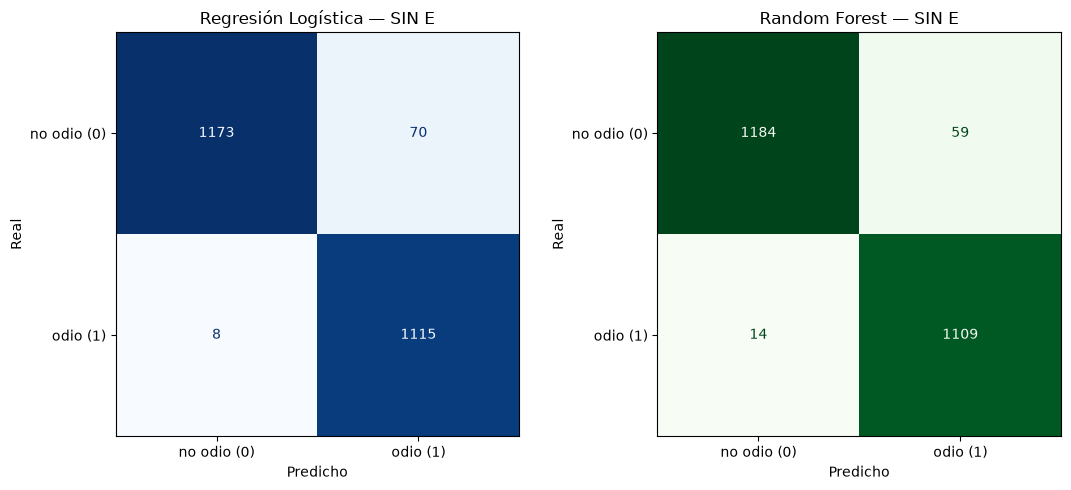

In [53]:

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr_noE, ax=axes[0], cmap="Blues", colorbar=False,
    display_labels=["no odio (0)", "odio (1)"])
axes[0].set_title("Regresión Logística — SIN E")
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf_noE, ax=axes[1], cmap="Greens", colorbar=False,
    display_labels=["no odio (0)", "odio (1)"])
axes[1].set_title("Random Forest — SIN E")
axes[1].set_xlabel("Predicho"); axes[1].set_ylabel("Real")

plt.tight_layout(); plt.show()

In [54]:
print("REGRESIÓN LOGÍSTICA — SIN E")
print(classification_report(y_test, y_pred_lr_noE, target_names=["no odio (0)", "odio (1)"], digits=3))

print("RANDOM FOREST — SIN E")
print(classification_report(y_test, y_pred_rf_noE, target_names=["no odio (0)", "odio (1)"], digits=3))

REGRESIÓN LOGÍSTICA — SIN E
              precision    recall  f1-score   support

 no odio (0)      0.993     0.944     0.968      1243
    odio (1)      0.941     0.993     0.966      1123

    accuracy                          0.967      2366
   macro avg      0.967     0.968     0.967      2366
weighted avg      0.968     0.967     0.967      2366

RANDOM FOREST — SIN E
              precision    recall  f1-score   support

 no odio (0)      0.988     0.953     0.970      1243
    odio (1)      0.949     0.988     0.968      1123

    accuracy                          0.969      2366
   macro avg      0.969     0.970     0.969      2366
weighted avg      0.970     0.969     0.969      2366



In [55]:
f1 = cross_val_score(model_lr_noE, X_train[num_features], y_train, cv=cv, scoring="f1_macro")
rec = cross_val_score(model_lr_noE, X_train[num_features], y_train, cv=cv, scoring="recall")
print(f"RL SIN E -> F1 macro: {f1.mean():.4f} ± {f1.std():.4f} // recall odio: {rec.mean():.4f} ± {rec.std():.4f}")
f1 = cross_val_score(model_rf_noE, X_train[num_features], y_train, cv=cv, scoring="f1_macro")
rec = cross_val_score(model_rf_noE, X_train[num_features], y_train, cv=cv, scoring="recall")
print(f"RF SIN E -> F1 macro: {f1.mean():.4f} ± {f1.std():.4f} // recall odio: {rec.mean():.4f} ± {rec.std():.4f}")

RL SIN E -> F1 macro: 0.9693 ± 0.0049 // recall odio: 0.9950 ± 0.0032
RF SIN E -> F1 macro: 0.9715 ± 0.0044 // recall odio: 0.9828 ± 0.0052


In [56]:
y_score_lr_noE = model_lr_noE.predict_proba(X_test[num_features])[:, 1]
y_score_rf_noE = model_rf_noE.predict_proba(X_test[num_features])[:, 1]

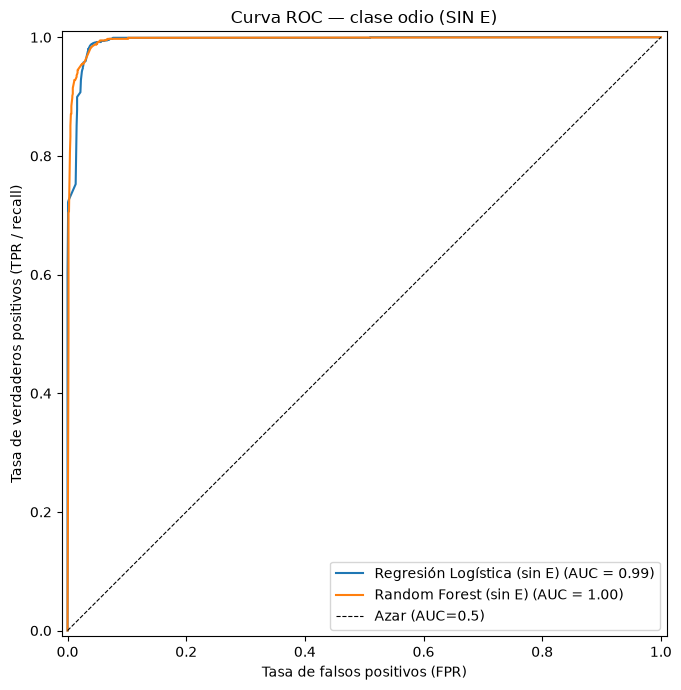

ROC-AUC RL sin E: 0.994
ROC-AUC RF sin E: 0.995


In [57]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, roc_auc_score

fig, ax = plt.subplots(figsize=(7, 7))
RocCurveDisplay.from_predictions(y_test, y_score_lr_noE, name="Regresión Logística (sin E)", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_score_rf_noE, name="Random Forest (sin E)", ax=ax)
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Azar (AUC=0.5)")
ax.set_title("Curva ROC — clase odio (SIN E)")
ax.set_xlabel("Tasa de falsos positivos (FPR)")
ax.set_ylabel("Tasa de verdaderos positivos (TPR / recall)")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

print("ROC-AUC RL sin E:", round(roc_auc_score(y_test, y_score_lr_noE), 3))
print("ROC-AUC RF sin E:", round(roc_auc_score(y_test, y_score_rf_noE), 3))

RESULTADOS:
1. Regresión Logística
- Sobre el conjunto de validación se alcanza una exactitud de 0.971 y un F1 macro de 0.971.
- Por clases, la clase odio tiene una precisión de 0.949 y un recall de 0.993. La clase no odio obtiene 0.993 y 0.952 respectivamente
- Los Falsos Negativos son 8 mensajes y los Falsos Positivos son 60.
- La curva ROC muestra un perfil muy sólido, muy alejado de la recta de azar.
- La validación cruzada confirma estabilidad: F1 macro es de 0.974 +/- 0.003 y recall de odio es 0.992 +/- 0.003.
- La diferencia de rendimiento entre datos de entrenamiento y validación confimran que no hay overfitting

2. Random Forest
- Sobre el conjunto de validación se alcanza una exactitud de 0.976 y un F1 macro de 0.976.
- Por clases, la clase odio tiene una precisión de 0.967 y un recall de 0.984. La clase no odio obtiene 0.985 y 0.969 respectivamente
- Los Falsos Negativos son 18 mensajes y los Falsos Positivos son 38.
- La curva ROC muestra un perfil muy sólido, muy alejado de la recta de azar.
- La validación cruzada confirma estabilidad: F1 macro es de 0.978 +/- 0.002 y recall de odio es 0.976 +/- 0.005.
- La diferencia de rendimiento entre datos de entrenamiento y validación confimran que no hay overfitting

COMPARATIVA

Ambos modelos obtienen resultados satisfactorios que confirman que son adecuados para la tarea requerida: consiguen clasificar los mensajes en odio/no_odio a partir de las características prporcionadas.
La diferencia en Falsos Negativos (8 vs 18) pone de manifiesto que la Regresión Logística prioriza el recall en sus decisiones internas (ideal para tarea de detección de odio). En cambio, Random Forest prioriza la precision, consiguiendo menos Falsos Positivos y mejor F1 macro (diferencia ligera en recall primando la experiencia de usuario al no cometer tantos errores).
Teniendo en cuenta todos los resultados, Random Forest es el mejor modelo para esta tarea de manera global, pero ambos son perfectamente adecuados.


EFECTO DE LA VARIABLE 'E'

Los experimentos realizados eliminando E del conjunto de datos muestra unos resultados muy similares (F1 macro con E: 0.971 / sin E:0.967 en Regresión Logística, curvas ROC muy similares, etc.). Por tanto, para el dataset suministrado, demostramos que el uso de 'E' no es necesario para obtener buenos resultados con los modelos seleccionados.
Sin embargo, cabe resaltar que esto es 'con el dataset suministrado', perfectamente balanceado y con longitudes de mensajes muy diferenciadas entre odio y no-odio. Caso de tener mensajes en "un canal real" sería posible que la importancia de la característica 'E' fuera muy superior.